## **IMPORT LIBRARY**

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

import pandas as pd
import re
import emoji
import numpy as np
from unidecode import unidecode
import string
from tqdm import tqdm
tqdm.pandas()
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
from sklearn.model_selection import train_test_split

# stopword
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# tokenizing
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

# stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# labeling
from transformers import pipeline

# embedding
import fasttext
import fasttext.util

# modeling
import tensorflow as tf
from tensorflow import keras
import nlpaug.augmenter.word as naw
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, 
    Dense, Dropout, LayerNormalization, 
    GlobalAveragePooling1D, Multiply, Permute, 
    Flatten, RepeatVector, Lambda, Concatenate, Layer, SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,  ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping

# evaluasi
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# tunning
import keras_tuner as kt

# inference
import sys
import os
sys.path.append(os.path.abspath(".."))
from script import scraping

[nltk_data] Downloading package stopwords to C:\Users\Ratuayu
[nltk_data]     Nurfajar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Ratuayu
[nltk_data]     Nurfajar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Ratuayu
[nltk_data]     Nurfajar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## **LOAD DATA**

In [2]:
# load dan read CSV
df = pd.read_csv('../data/bpjs_reviews_1.csv')
for i in range(1,5):
    file_name = f'../data/bpjs_reviews_{i+1}.csv'
    df_next = pd.read_csv(file_name)
    df = pd.concat([df, df_next], ignore_index=True)

## **DATA INSPECTION**

In [3]:
# overview 5 data pertama
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,15664a80-253a-42d9-b192-bf2d8ed1f605,Gp Pone,https://play-lh.googleusercontent.com/a-/ALV-U...,"niat hati pengen bayar iyuran,tapi yo nak ono ...",1,0,4.14.0,2025-10-26 02:21:27,NaN,NaN,4.14.0
1,8a5f2389-f330-4e1d-ad1b-0dee22b18ef6,Irma Marlin,https://play-lh.googleusercontent.com/a/ACg8oc...,"kenapa hari aku bayar BPJS, tiba2 aku mau cek ...",1,0,4.14.0,2025-10-26 00:30:09,NaN,NaN,4.14.0
2,4b0510af-27c9-4048-ac6a-f649287eedf9,Rochmat RACHMATULLOH,https://play-lh.googleusercontent.com/a-/ALV-U...,"Aplikasi log out melulu,masuk lagi susah..",1,0,NaN,2025-10-26 00:06:09,NaN,NaN,NaN
3,2b31412f-25be-4354-828e-8ddde0a58cf8,mulyono mahrudin,https://play-lh.googleusercontent.com/a/ACg8oc...,nomor hp msih aktif smpai skrng udah 10thn leb...,1,0,NaN,2025-10-25 22:46:43,NaN,NaN,NaN
4,739ea2bf-2273-4dff-baed-2e780c39a075,Goblag88 Agus,https://play-lh.googleusercontent.com/a/ACg8oc...,aplikasi sampah udah masuk update ga bisa masu...,1,0,NaN,2025-10-25 21:45:03,NaN,NaN,NaN


In [4]:
# overview 5 data terakhir
df.tail()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
19995,3106f233-8912-4608-85ca-d30a01405eef,Ahmad Rizal,https://play-lh.googleusercontent.com/a/ACg8oc...,aplikasinya bagus banget mau urus bpjs responn...,5,0,4.13.1,2025-09-10 14:00:51,Hi... Terima kasih atas review dan rating yang...,2025-09-16 09:54:58,4.13.1
19996,1b9ab387-0df1-4ab3-914f-c984a6d2878c,Jang Oma,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap,5,0,NaN,2025-09-10 13:53:36,Hi... Terima kasih atas review dan rating yang...,2025-09-16 09:56:49,NaN
19997,50d26611-85cb-41c1-9e47-c824b0957db4,Desi Rahayu,https://play-lh.googleusercontent.com/a-/ALV-U...,memudahkan dalam perawatan kesehatan,5,0,4.13.1,2025-09-10 13:29:38,Hi... Terima kasih atas review dan rating yang...,2025-09-16 09:56:46,4.13.1
19998,fd4b7c52-dfe3-4b0c-b80e-3482de2cc435,SYAHRIL,https://play-lh.googleusercontent.com/a/ACg8oc...,👍👍👍👍👍,5,0,4.13.1,2025-09-10 12:50:58,Hi... Terima kasih atas review dan rating yang...,2025-09-16 09:57:01,4.13.1
19999,c8a0996a-6e08-4242-95dd-8a2eb5685255,evy sari,https://play-lh.googleusercontent.com/a/ACg8oc...,puas dengan pelayanan pandawa bpjs,5,0,4.13.1,2025-09-10 12:48:31,Hi... Terima kasih atas review dan rating yang...,2025-09-16 09:56:42,4.13.1


In [5]:
# cek dimensi
df.shape

(20000, 11)

💡**Interpretasi**<br>
Terdapat total 20.000 data review bpjs hasil scrapping.

In [6]:
# cek informasi data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              20000 non-null  str  
 1   userName              20000 non-null  str  
 2   userImage             20000 non-null  str  
 3   content               20000 non-null  str  
 4   score                 20000 non-null  int64
 5   thumbsUpCount         20000 non-null  int64
 6   reviewCreatedVersion  15960 non-null  str  
 7   at                    20000 non-null  str  
 8   replyContent          16132 non-null  str  
 9   repliedAt             16132 non-null  str  
 10  appVersion            15960 non-null  str  
dtypes: int64(2), str(9)
memory usage: 1.7 MB


💡**Interpretasi**<br>
Total 5 kolom terakhir ada missing value, tapi yang akan digunakan analisis hanya kolom `content` saja untuk keperluan analisis sentimen.

In [7]:
# melihat tipe data setiap kolom
df.dtypes

reviewId                  str
userName                  str
userImage                 str
content                   str
score                   int64
thumbsUpCount           int64
reviewCreatedVersion      str
at                        str
replyContent              str
repliedAt                 str
appVersion                str
dtype: object

In [8]:
# analisis statistik deskripsi
df.describe(include='all')

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
count,20000,20000,20000,20000,20000.000000,20000.000000,15960,20000,16132,16132,15960
unique,20000,19678,19974,16891,NaN,NaN,42,19970,296,15756,42
top,15664a80-253a-42d9-b192-bf2d8ed1f605,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,NaN,NaN,4.13.1,2025-10-16 11:29:15,Mohon maaf atas ketidaknyamanannya. Terkait ke...,2025-10-06 14:01:39,4.13.1
freq,1,27,27,284,NaN,NaN,4379,2,3962,4,4379
mean,NaN,NaN,NaN,NaN,3.000000,0.829350,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.414249,14.340112,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.000000,0.000000,NaN,NaN,NaN,NaN,NaN


## **DATA PREPROCESSING**

### **DATA CLEANING**

In [9]:
# seleksi fitur
df_clean = df[['content']]
df_clean

,content
0,"niat hati pengen bayar iyuran,tapi yo nak ono ..."
1,"kenapa hari aku bayar BPJS, tiba2 aku mau cek ..."
2,"Aplikasi log out melulu,masuk lagi susah.."
3,nomor hp msih aktif smpai skrng udah 10thn leb...
4,aplikasi sampah udah masuk update ga bisa masu...
...,...
19995,aplikasinya bagus banget mau urus bpjs responn...
19996,mantap
19997,memudahkan dalam perawatan kesehatan
19998,👍👍👍👍👍


In [10]:
# pembuatan fungsi pembersih

# lowercase + normalisasi karakter
def normalize_text(text):
    text = text.lower()
    text = unidecode(text)
    return text

# menghapus emoji
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

# membersihkan teks
def cleaning(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', ' ', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

# memecah teks jadi token
def tokenizing(text):
    return text.split()

# memperbaiki kata slang
slangwords = {
    "apk": "aplikasi",
    "apknya": "aplikasinya",
    "log": "login",
    "lg in": "login",
    "lgin": "login",
    "tdk": "tidak",
    "gk": "tidak",
    "ga": "tidak",
    "gbs": "tidak bisa",
    "lemot": "lambat",
    "errorrr": "error",
    "updatean": "pembaruan",
    "updatenya": "pembaruannya",
    "force close": "tertutup sendiri",
    "bpjs": "BPJS",
    "antri": "antre",
    "ngantri": "antre",
    "puskes": "puskesmas",
    "rujukanya": "rujukannya",
    "verif": "verifikasi",
    "verivikasi": "verifikasi",
    "plis": "tolong",
    "pliss": "tolong",
    "bgus": "bagus",
    "bgs": "bagus",
    "mantapp": "mantap",
    "mantabb": "mantap",
    "kereeen": "keren",
    "mksh": "terima kasih",
    "thx": "terima kasih",
    "dgn": "dengan",
    "sm": "sama",
    "klo": "kalau",
    "udh": "sudah",
    "blm": "belum",
    "trs": "terus",
    "hrs": "harus",
    "pengen": "ingin",
    "thn": "tahun",
    "smpai": "sampai",
    "sdh": "sudah",
    "msih": "masih",
    "hp": "handphone",
    "blm": "belum",
    "iyuran": "iuran",
    "tungakan": "tunggakan",
    "skrng": "sekarang",
    "yg": "yang",
    "bagu": "bagus",
    "tdi": "tadi",
    "bagu": "bagus",
    "bgs": "bagus"
}

def fix_slangwords(token):
    fixed_words = []
 
    for word in token:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    return fixed_words

# handling negation
def handle_negation(token):
    negation_words = [
    "tidak", "bukan", "tak", "belum", "jangan",
    "enggak", "gak", "nggak", "ga", "ndak", "ngga", "nggk", "nda",
    "tdk", "tdak", "tdkbs", "gk", "g", "gaaa", "gakkk", "nggakk",
    "gabisa", "gakbisa", "gaada", "gapunya", "gakjalan", "gagal",
    "tdkbisa", "tdkad", "tdkjalan", "takbisa", "ndakbisa",
    "nope", "nggaaa", "ndaa"
]
    new_tokens = []
    skip_next = False

    for i, word in enumerate(token):
        if skip_next:
            skip_next = False
            continue
        
        if word in negation_words and i + 1 < len(token):
            new_tokens.append(f"tidak_{token[i+1]}")
            skip_next = True
        else:
            new_tokens.append(word)

    return new_tokens

# stopword removel
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())
nltk_stopwords = set(stopwords.words('indonesian'))
custom_stopwords = {
    'iya','yaa','gak','nya','na','sih','ku','di','ga','ya','gaa',
    'loh','kah','woi','woii','woy','lah','wong','ono','yo','yoo'
}

all_stopwords = sastrawi_stopwords | nltk_stopwords | custom_stopwords

def stopword_removel(tokens):
    return [word for word in tokens if word not in all_stopwords]

# mengubah token jadi bentuk dasar
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(token):
    return [stemmer.stem(word) for word in token]

def join_tokens(tokens):
    return ' '.join(tokens)

In [11]:
# pembuatan pipeline cleaning full untuk training
def pipeline_cleaning_full(text):
    if pd.isna(text):
        return []
    
    # normalization
    text = normalize_text(text)

    # menghapus emoji
    text = remove_emoji(text)

    # cleaning
    text = cleaning(text)
    
    # tokenizing
    tokens = tokenizing(text)

    # menangani slangword
    tokens = fix_slangwords(tokens)

    # menangani kata negasi
    tokens = handle_negation(tokens)

    # menghapus kata yang tidak penting
    tokens = stopword_removel(tokens)

    # mengubah ke katadalam bentuk dasar
    tokens = stemming(tokens)

    # join token
    text = join_tokens(tokens)

    return text

# pembuatan pipeline cleaning sebagian untuk labeling
def pipeline_cleaning_labeling(text):
    if pd.isna(text):
        return []
    
    # normalization
    text = normalize_text(text)

    # menghapus emoji
    text = remove_emoji(text)

    # cleaning
    text = cleaning(text)

    # tokenizing
    tokens = tokenizing(text)

    # menangani slangword
    tokens = fix_slangwords(tokens)

    # join token
    text = join_tokens(tokens)

    return text

# proses batch
def cleaning_per_batches(series, func, batch_size=500):
    results = []

    for i in tqdm(range(0, len(series), batch_size)):
        print(f'Processing Batch {i}')
        batch = series.iloc[i:i+batch_size]
        processed = batch.apply(func)
        results.extend(processed)
        print()

    return results

In [12]:
df_clean['clean_label'] = df_clean['content'].apply(pipeline_cleaning_labeling)

In [13]:
df_clean.head()

,content,clean_label
0,"niat hati pengen bayar iyuran,tapi yo nak ono ...",niat hati ingin bayar iuran tapi yo nak ono tu...
1,"kenapa hari aku bayar BPJS, tiba2 aku mau cek ...",kenapa hari aku bayar BPJS tiba aku mau cek su...
2,"Aplikasi log out melulu,masuk lagi susah..",aplikasi login out melulu masuk lagi susah
3,nomor hp msih aktif smpai skrng udah 10thn leb...,nomor handphone masih aktif sampai sekarang ud...
4,aplikasi sampah udah masuk update ga bisa masu...,aplikasi sampah udah masuk update tidak bisa m...


### **LABELING**

In [14]:
# inisialisasi model
pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

nlp = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name
)

# proses labeling
df_label = df_clean.copy()
df_label['label'] = df_clean['clean_label'].progress_apply(
    lambda x: nlp(x)[0]['label']
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 213.82it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 20000/20000 [14:40<00:00, 22.72it/s]


In [15]:
df_label['label'].value_counts()

label
negative    11971
positive     5021
neutral      3008
Name: count, dtype: int64

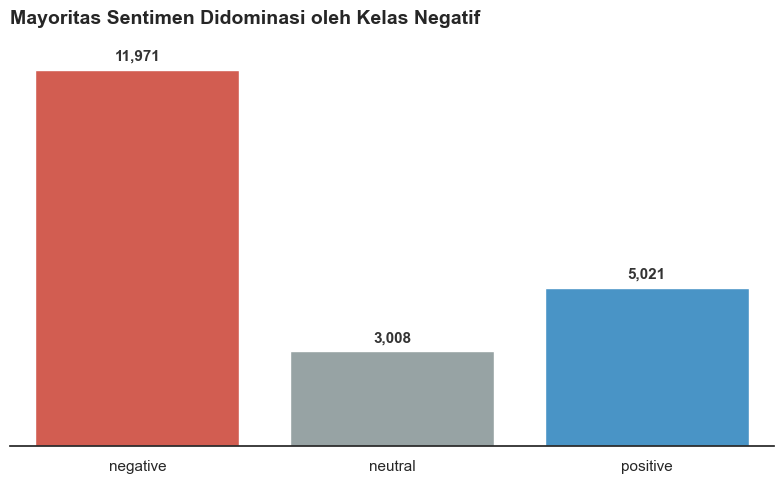

In [16]:
# visualisasi distribusi kelas
sns.set_theme(style="white")
plt.figure(figsize=(8, 5))
custom_colors = ['#e74c3c', '#95a5a6', '#3498db'] 

ax = sns.countplot(
    data=df_label,
    x='label',
    hue='label', 
    palette=custom_colors,
    order=['negative', 'neutral', 'positive'],
    legend=False 
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#333333')

plt.title('Mayoritas Sentimen Didominasi oleh Kelas Negatif', 
          fontsize=14, fontweight='bold', pad=20, loc='left')

plt.xlabel('') 
plt.ylabel('') 

ax.set_yticks([]) 

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

💡**Interpretasi**<br>
- Distribusi sentimen memiliki ketimpangan yang tajam (class imbalance), dimana kelas **negative** itu mendominasi dengan jumlah **11.971** ulasan dibanding kelas positive dan neutral.
- Strategi pemodelannya akan melakukan resampling dengan `SMOTE`, `Augmentasi Text`, atau mengimplementasikan `class wights` dan `stratified split`, kmeudian untuk matrik evaluasinya mempertimbangakan score `Macro F1` karena lebih robust terhadap imbalance class dan multi kelas.
- Berdasarkan sentimen ulasan, besarnya angka sentimen negative memberikan sinyal **darurat** bahwa **mayoritas pengalaman pengguna** saat ini didominasi oleh **kendala/kekecewaan** 

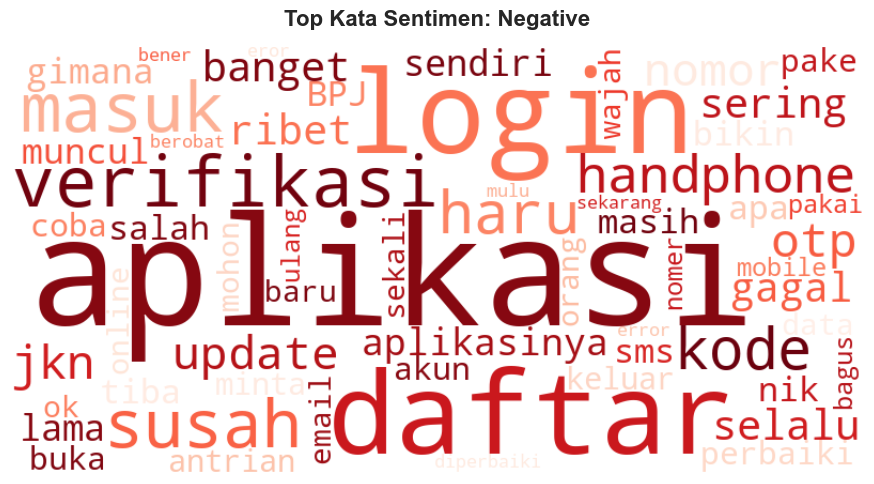

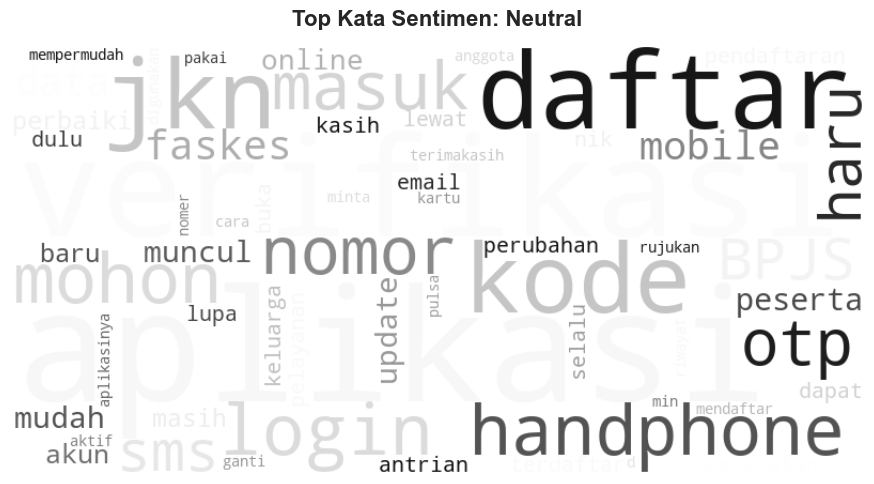

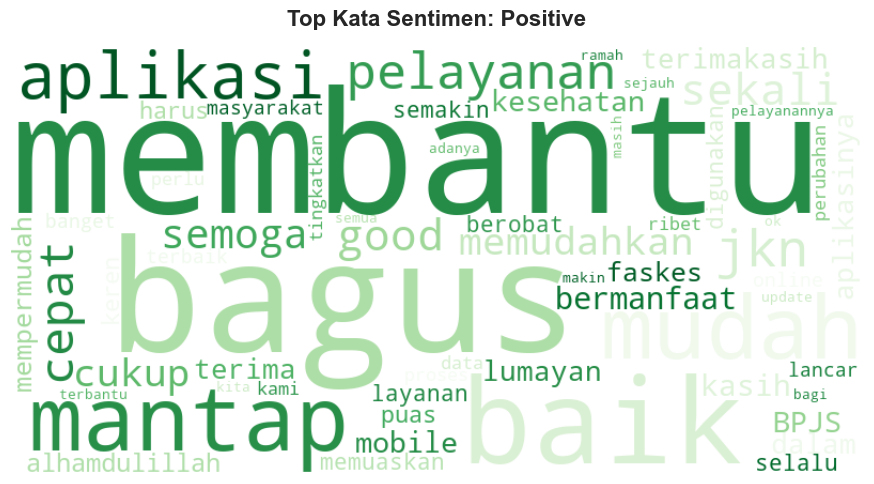

In [17]:
# visualisasi wordcloud untuk melihat distirubusi kata dalam setiap kelas/label
custom_stopwords = set(STOPWORDS)
id_stopwords = {
    "di", "ini", "saya", "bisa", "tidak", "nya", "buat", "dan", "yang", "yg",
    "ke", "dari", "aja", "untuk", "udah", "sudah", "dengan", "itu", "ada",
    "lagi", "terus", "padahal", "kalau", "kalo", "karena", "sama", "kok",
    "punya", "banyak", "sih", "juga", "atau", "jadi", "pas", "gak", "ga", 
    "ngga", "nggak", "kan", "tapi", "tp", "ya", "dong", "biar", "lebih",
    "sangat", "kali", "saat", "belum", "saja", "mau", "malah", "tolong", "kenapa"
}
custom_stopwords.update(id_stopwords)

labels = df_label['label'].unique()

for label in labels:
    text = ' '.join(df_label[df_label['label'] == label]['clean_label'].astype(str))

    if label == 'negative':
        cmap = 'Reds'     
    elif label == 'positive':
        cmap = 'Greens'   
    else:
        cmap = 'Greys'   

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords, 
        max_words=60,              
        colormap=cmap,          
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    
    plt.title(f'Top Kata Sentimen: {label.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

💡**Interpretasi**<br>
1. **Sentimen Positif:**
- Kata-kata yang paling mendominasi pada wordcloud sentimen positif adalah "membantu", "baik", "bagus", "mantap", dan "mudah".
- Hal ini mengindikasikan bahwa ketika aplikasi berjalan lancar, pengguna merasa sangat puas dan terbantu.
- Kehadiran kata seperti "mempermudah", "cepat", dan "bermanfaat" menunjukkan bahwa aplikasi ini berhasil mencapai tujuannya dalam memberikan efisiensi layanan bagi penggunanya.

2. **Sentimen Netral:**
- Pada sentimen netral, percakapan didominasi oleh kata "verifikasi", "kode", "daftar", "login", dan "nomor".
- Terdapat juga kemunculan kata-kata teknis pendukung seperti "otp", "sms", "handphone", dan "akun".
- Ulasan netral ini umumnya terfokus pada proses administratif. Pengguna lebih banyak berdiskusi, bertanya, atau melaporkan tahapan teknis terkait pendaftaran akun dan pengiriman kode verifikasi tanpa sentimen emosional yang kuat.

3. **Sentimen Negatif:**
- Visualisasi sentimen negatif sangat menonjolkan kata "aplikasi", "verifikasi", "daftar", "login", dan "masuk".
- Masalah utama diperjelas dengan munculnya kata keluhan seperti "susah", "ribet", "gagal", "error", dan "lama".
- Ini merupakan indikasi kuat bahwa titik lemah (pain point) utama aplikasi berada pada fase awal penggunaan. Pengguna sering kali merasa frustrasi karena terhambat di tahap verifikasi (termasuk masalah "kode" dan "otp") atau saat mencoba masuk ke dalam aplikasi.

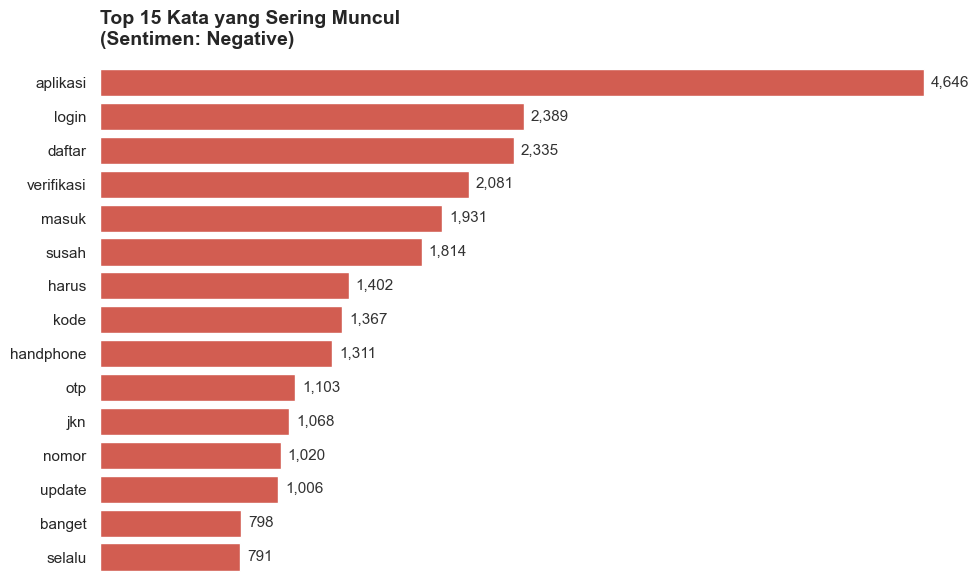

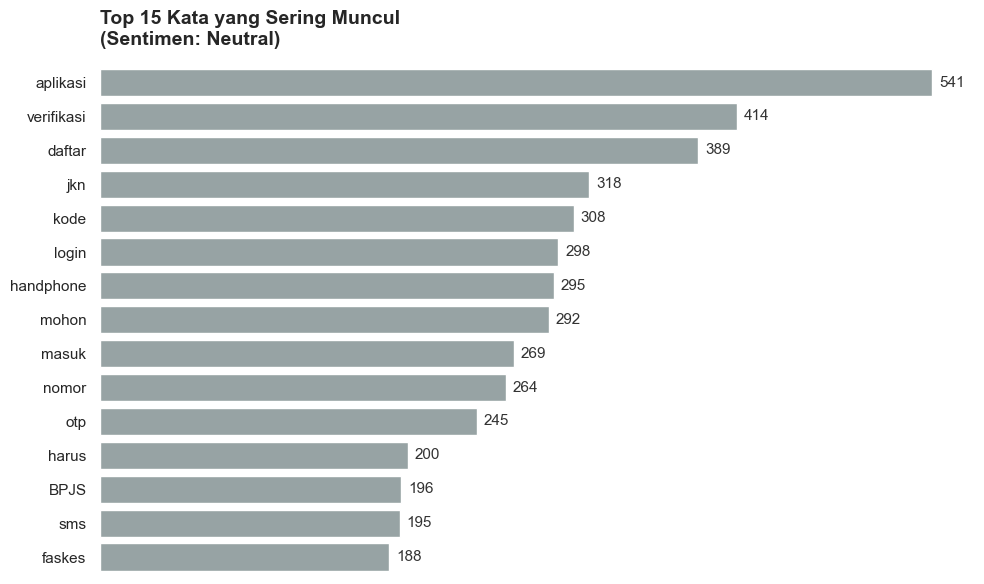

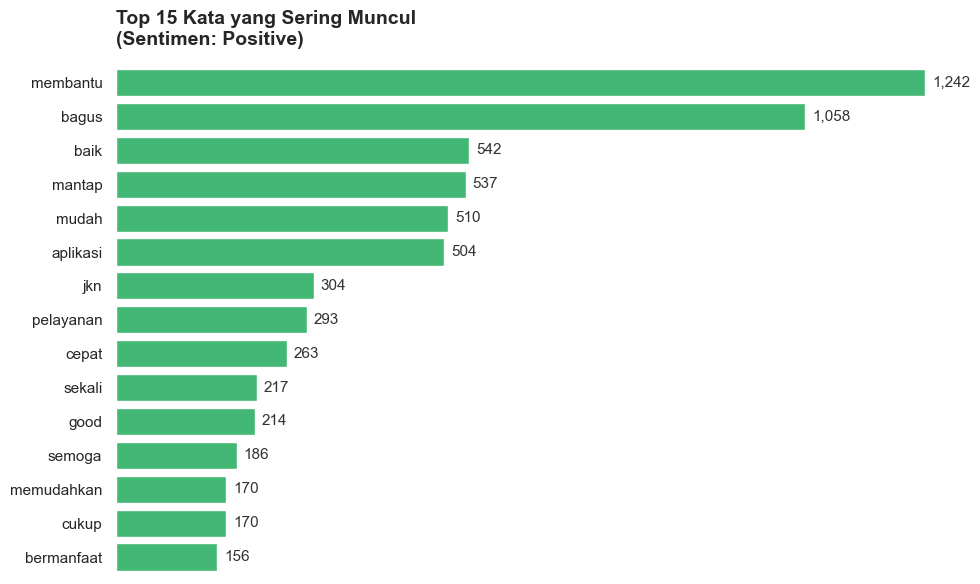

In [18]:
# visualisasi top 15 kata di setiap kelas
labels = df_label['label'].unique()

for label in labels:
    text = ' '.join(df_label[df_label['label'] == label]['clean_label'].astype(str))
    words = text.split()

    filtered_words = [word for word in words if word not in custom_stopwords]
    
    word_counts = Counter(filtered_words)
    top_15_words = word_counts.most_common(15)

    words_list = [item[0] for item in top_15_words]
    counts_list = [item[1] for item in top_15_words]

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")
    
    if label == 'negative':
        color = '#e74c3c' 
    elif label == 'positive':
        color = '#2ecc71' 
    else:
        color = '#95a5a6' 
        
    ax = sns.barplot(x=counts_list, y=words_list, color=color)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), # Jarak teks dari bar
                    textcoords='offset points',
                    fontsize=11, color='#333333')
        
    plt.title(f'Top 15 Kata yang Sering Muncul\n(Sentimen: {label.capitalize()})', 
              fontsize=14, fontweight='bold', pad=15, loc='left')
    plt.xlabel('') 
    plt.ylabel('')
    ax.set_xticks([]) 
    sns.despine(left=True, bottom=True) 
    
    plt.tight_layout()
    plt.show()

💡**Interpretasi**<br>
1. **Sentimen Negatif:**<br>
Adanya kata **"susah"** sebanyak 1.814 kali mengonfirmasi bahwa proses otentikasi (yang juga melibatkan kata "kode", "handphone", dan "otp") menjadi **bottleneck utama** yang membuat pengguna frustrasi.

2. **Sentimen Netral:**<br>
Adanya kata **"mohon"** (292 kemunculan) mengindikasikan bahwa ulasan netral banyak digunakan sebagai **sarana pelaporan kendala teknis atau pengajuan bantuan kepada pihak pengembang**, bukan sekadar memberikan rating biasa.

3. **Sentimen Positif:**<br>
Adanya kata **"mudah"** (510 kemunculan) dan **"cepat"** (263 kemunculan) menunjukkan bahwa jika pengguna berhasil melewati login dan verifikasi, mereka mendapatkan **manfaat efisiensi layanan**.

### **FEATURE ENGINEERING**

#### **FEATURE SELECTION**

In [141]:
df_select = df_label[['content', 'label']]
df_select.head()

,content,label
0,"niat hati pengen bayar iyuran,tapi yo nak ono ...",negative
1,"kenapa hari aku bayar BPJS, tiba2 aku mau cek ...",negative
2,"Aplikasi log out melulu,masuk lagi susah..",negative
3,nomor hp msih aktif smpai skrng udah 10thn leb...,negative
4,aplikasi sampah udah masuk update ga bisa masu...,negative


In [20]:
import requests

def kirim_notif_telegram(pesan):
    # Jangan lupa isi 2 variabel di bawah ini dengan token dan ID milikmu
    bot_token = '8526450142:AAErdplkokgy73usixJP-raboyT1DDNxe6k'
    chat_id = '984210152'
    
    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    payload = {"chat_id": chat_id, "text": pesan}
    try:
        requests.post(url, json=payload)
    except Exception as e:
        print(f"Gagal kirim notif: {e}")

In [21]:
# eksekusi pipeline full cleaning
df_select['clean'] = df_select['content'].progress_apply(pipeline_cleaning_full)

100%|██████████| 20000/20000 [17:42<00:00, 18.83it/s] 


In [22]:
df_select = df_select[['clean','label']]
df_select.head()

,clean,label
0,niat hati bayar iur nak tunggak bayar ngaktifi...,negative
1,bayar bpjs cek aktf tidak pas cek siang aktf m...,negative
2,aplikasi login out melulu masuk susah,negative
3,nomor handphone aktif udah tidak prnah daftar ...,negative
4,aplikasi sampah udah masuk update tidak bisa m...,negative


#### **SPLIT DATA**

In [23]:
X = df_select['clean']
y = df_select['label']

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# cek dimensi
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((16000,), (16000,), (4000,), (4000,))

In [25]:
y_val

12653    negative
1906     negative
6183     negative
14002    negative
8453     negative
           ...   
2423     negative
14911     neutral
16242    positive
9828      neutral
16030    negative
Name: label, Length: 4000, dtype: str

#### **AUGEMENTASI**

In [26]:
# # notif
# pesan_sukses = "Halo Ratu, Prosesnya Udah Selesai."
# kirim_notif_telegram(pesan_sukses)

In [85]:
# load model fastext
model_path = r'..\embedding\cc.id.300.vec\cc.id.300.vec'

# inisialisasi augmenter
aug = naw.WordEmbsAug(
    model_type='fasttext', 
    model_path=model_path,
    action="substitute",
    aug_p=0.2
)
print("Model berhasil dimuat!")

# menggabungkan data
df_train = pd.DataFrame({
    'new_text': x_train.reset_index(drop=True),
    'sentimen': y_train.reset_index(drop=True)
})

Model berhasil dimuat!


In [86]:
df_train.head()

,new_text,sentimen
0,gajelas bagt gbisa ngirim otp udah ganti nomor...,negative
1,tidak sesuai lapang jadwal tgl agsts pas mlh s...,negative
2,keren,positive
3,aplikasi tekeluar error pas daftar kontrol pok...,negative
4,sie login trz sandi slah,negative


In [88]:
# fungsi augmentasi
def augmentasi_dataframe(df_minority, label_kelas, jumlah_variasi):
    teks_baru = []
    label_baru = []
    
    for teks in tqdm(df_minority['new_text'], desc=f"Augmentasi Kelas {label_kelas}"):
        augmented_results = aug.augment(teks, n=jumlah_variasi)
        
        # Penanganan jika hasil kembalian berupa string (n=1)
        if isinstance(augmented_results, str):
            augmented_results = [augmented_results]
            
        teks_baru.extend(augmented_results)
        label_baru.extend([label_kelas] * len(augmented_results))
        
    return pd.DataFrame({'new_text': teks_baru, 'sentimen': label_baru})

# eksekusi augmentasi
df_negative = df_train[df_train['sentimen'] == 'negative']
df_positive = df_train[df_train['sentimen'] == 'positive']
df_neutral = df_train[df_train['sentimen'] == 'neutral']

print("Augmentasi Kelas Positif")
df_positive_aug = augmentasi_dataframe(df_positive, 'positive', jumlah_variasi=1)
print("Augmentasi Kelas Neutral")
# df_neutral_aug = augmentasi_dataframe(df_neutral, 'neutral', jumlah_variasi=3)
df_neutral_aug = augmentasi_dataframe(df_neutral, 'neutral', jumlah_variasi=2)

Augmentasi Kelas Positif


Augmentasi Kelas positive: 100%|██████████| 4017/4017 [10:08<00:00,  6.60it/s]


Augmentasi Kelas Neutral


Augmentasi Kelas neutral: 100%|██████████| 2406/2406 [18:01<00:00,  2.22it/s]


In [89]:
print("Menggabungkan Kelas")
df_train_final = pd.concat([df_train, df_positive_aug, df_neutral_aug], ignore_index=True)
df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

x_train_aug = df_train_final['new_text']
y_train_aug = df_train_final['sentimen']
 
print("Selesai")

Menggabungkan Kelas
Selesai


In [90]:
y_train_aug.value_counts()

sentimen
negative    9577
positive    7801
neutral     7078
Name: count, dtype: int64

#### **FEATURES TRANSFORM**

In [91]:
# tokenisasi
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(x_train_aug)
vocab_size = len(tokenizer.word_index) + 1
print(f"Jumlah kosakata (vocab) unik: {vocab_size} kata")

# mengubah teks menjadi angka indeks (sequencing)
x_train_seq = tokenizer.texts_to_sequences(x_train_aug)
x_val_seq = tokenizer.texts_to_sequences(x_val) 

Jumlah kosakata (vocab) unik: 13480 kata


In [92]:
x_train_seq

[[24],
 [234, 1467, 93, 4091],
 [1831],
 [348, 171],
 [56, 9, 82],
 [88, 147, 2, 7, 21, 45, 6131, 3],
 [14, 9],
 [10, 49, 27],
 [142, 193, 6132, 71, 16],
 [2974, 3, 11, 2, 105, 85, 163],
 [2975, 13, 18, 1832, 2976, 6133, 6134],
 [2, 181, 3, 12, 40, 221, 194, 181, 181, 263, 19, 409, 21, 189, 1049],
 [1833, 580, 6, 2977, 15, 51, 23, 15, 250, 51, 247, 190, 21, 14],
 [6135, 4092, 19, 2978, 6136, 224],
 [4093, 3, 7, 104, 75, 607],
 [85,
  8,
  66,
  56,
  12,
  90,
  7,
  19,
  2979,
  21,
  214,
  141,
  2,
  4,
  2,
  1005,
  66,
  55,
  5,
  41,
  2,
  4,
  66,
  55,
  3,
  3,
  2,
  4,
  66,
  332,
  72,
  48,
  19,
  66,
  28,
  3,
  2,
  310,
  58,
  763,
  3,
  284,
  205,
  764],
 [45, 97, 9, 280, 151, 153, 2, 4, 8, 21, 5, 41],
 [360,
  2,
  4,
  7,
  569,
  2,
  202,
  166,
  111,
  306,
  46,
  76,
  19,
  15,
  2980,
  216,
  2,
  4,
  25,
  100,
  16],
 [217,
  25,
  11,
  12,
  7,
  569,
  6137,
  47,
  203,
  14,
  6138,
  6139,
  2981,
  6140,
  181,
  2,
  491,
  75],
 [20, 

In [96]:
# padding
max_length = 60
x_train_pad = pad_sequences(x_train_seq, maxlen=max_length, padding='post', truncating='post')
x_val_pad = pad_sequences(x_val_seq, maxlen=max_length, padding='post', truncating='post')

In [97]:
x_train_pad

array([[  24,    0,    0, ...,    0,    0,    0],
       [ 234, 1467,   93, ...,    0,    0,    0],
       [1831,    0,    0, ...,    0,    0,    0],
       ...,
       [ 486,  101,    0, ...,    0,    0,    0],
       [  18,    6,   23, ...,    0,    0,    0],
       [  37,    5, 1369, ...,    0,    0,    0]],
      shape=(24456, 60), dtype=int32)

In [102]:
# load model embedding
ft_model = fasttext.load_model('..\embedding\cc.id.300.bin')

# mereduksi dimensi 300 ke 100
fasttext.util.reduce_model(ft_model, 100)

# embedding_dim = 300
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

embedding_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(13480, 100))

In [103]:
# embedding representasi vektor
kata_ditemukan = 0
kata_tidak_ditemukan = 0

for word, i in tokenizer.word_index.items():
    if word in ft_model:
        embedding_matrix[i] = ft_model[word]
        kata_ditemukan += 1
    else:
        kata_tidak_ditemukan += 1

print(f"Selesai! {kata_ditemukan} kata ditemukan vektornya, {kata_tidak_ditemukan} kata tidak ditemukan.")

Selesai! 11255 kata ditemukan vektornya, 2224 kata tidak ditemukan.


In [104]:
# encoding label
y_train_enc = y_train_aug.map({'negative' : 0 , 'neutral' : 1 , 'positive' : 2})
y_val_enc = y_val.map({'negative' : 0 , 'neutral' : 1 , 'positive' : 2})

y_train_enc, y_val_enc

(0        1
 1        1
 2        2
 3        0
 4        2
         ..
 24451    1
 24452    0
 24453    2
 24454    1
 24455    1
 Name: sentimen, Length: 24456, dtype: int64,
 12653    0
 1906     0
 6183     0
 14002    0
 8453     0
         ..
 2423     0
 14911    1
 16242    2
 9828     1
 16030    0
 Name: label, Length: 4000, dtype: int64)

## **MODELING**

### **MODEL BASELINE**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=True  
    ),

    tf.keras.layers.SpatialDropout1D(0.3),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            96,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    ),

    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ (None, 60, 100)        │     1,348,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_35                │ (None, 60, 192)        │       151,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 192)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,511,843 (5.77 MB)

 Trainable params: 1,511,843 (5.77 MB)

 Non-trainable params: 0 (0.00 B)

In [158]:
# inisialisasi callback
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    )
]

In [159]:
# inisialisasi class weight untuk penanganan class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.8512060144095228), 1: np.float64(1.1517377790336254), 2: np.float64(1.044994231508781)}


In [160]:
# training model
history = model.fit(
    x_train_pad,
    y_train_enc,
    validation_data=(x_val_pad, y_val_enc),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# history = model.fit(
#     x_train_pad,
#     y_train_enc,
#     validation_data=(x_val_pad, y_val_enc),
#     epochs=20,
#     batch_size=64,
#     callbacks=callbacks,
#     verbose=1
# )

Epoch 1/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 155s 385ms/step - accuracy: 0.6503 - loss: 0.7873 - val_accuracy: 0.7377 - val_loss: 0.5888 - learning_rate: 5.0000e-04
Epoch 2/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 208s 400ms/step - accuracy: 0.7794 - loss: 0.5609 - val_accuracy: 0.7523 - val_loss: 0.5628 - learning_rate: 5.0000e-04
Epoch 3/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 152s 398ms/step - accuracy: 0.8226 - loss: 0.4674 - val_accuracy: 0.7920 - val_loss: 0.4860 - learning_rate: 5.0000e-04
Epoch 4/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 151s 395ms/step - accuracy: 0.8476 - loss: 0.4025 - val_accuracy: 0.8077 - val_loss: 0.4726 - learning_rate: 5.0000e-04
Epoch 5/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 203s 398ms/step - accuracy: 0.8680 - loss: 0.3600 - val_accuracy: 0.7995 - val_loss: 0.4928 - learning_rate: 5.0000e-04
Epoch 6/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 149s 390ms/step - accuracy: 0.8799 - loss: 0.3262 - val_accuracy: 0.8060 - val_loss: 0.4894 - learning_rate: 5.0000e-04
Epoch 7/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 

In [161]:
# fungsi untuk evaluasi performa terhadap dataset
def evaluasi_model(model_eval, x_data, y_true, dataset_name):
    y_pred_prob = model_eval.predict(x_data)
    
    y_pred_classes = np.argmax(y_pred_prob, axis=1)
    
    target_names = ['Negative', 'Neutral', 'Positive']

    loss, accuracy = model.evaluate(x_data, y_true, verbose=0)

    print(f"\n===== EVALUATION {dataset_name.upper()} =====")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    
    print(f"\n{'='*40}")
    print(f" CLASSIFICATION REPORT - {dataset_name.upper()}")
    print(f"{'='*40}")
    print(classification_report(y_true, y_pred_classes, target_names=target_names))
    
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {dataset_name}')
    plt.ylabel('Label Asli')
    plt.xlabel('Prediksi Model')
    plt.show()

def plot_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
    ax1.set_title('Kurva Akurasi Model')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Akurasi')
    ax1.legend(loc='lower right')

    ax2.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
    ax2.set_title('Kurva Loss Model')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

def plot_roc_auc_multiclass(y_true, y_pred_prob):
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = y_true_bin.shape[1]
    target_names = ['Negative', 'Neutral', 'Positive']
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Mulai menggambar Kurva
    plt.figure(figsize=(8, 6))
    colors = cycle(['red', 'gray', 'blue'])
    
    for i, color, label in zip(range(n_classes), colors, target_names):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC {label} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR) / Recall')
    plt.title('Kurva ROC-AUC Multi-Kelas')
    plt.legend(loc="lower right")
    plt.show()

765/765 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step

===== EVALUATION DATA TRAINING =====
Loss     : 0.3017
Accuracy : 0.8891

 CLASSIFICATION REPORT - DATA TRAINING
              precision    recall  f1-score   support

    Negative       0.86      0.94      0.90      9577
     Neutral       0.89      0.81      0.85      7078
    Positive       0.92      0.90      0.91      7801

    accuracy                           0.89     24456
   macro avg       0.89      0.88      0.89     24456
weighted avg       0.89      0.89      0.89     24456



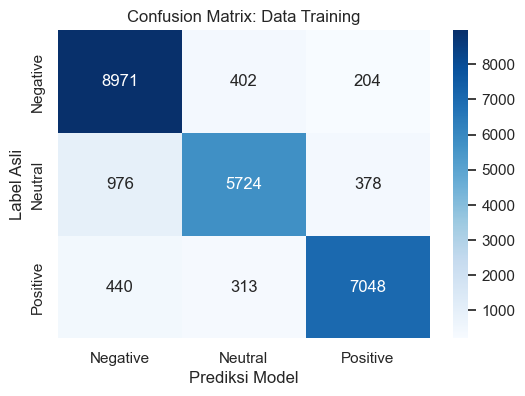

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step

===== EVALUATION DATA VALIDASI =====
Loss     : 0.4726
Accuracy : 0.8077

 CLASSIFICATION REPORT - DATA VALIDASI
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87      2394
     Neutral       0.50      0.45      0.47       602
    Positive       0.88      0.83      0.85      1004

    accuracy                           0.81      4000
   macro avg       0.74      0.72      0.73      4000
weighted avg       0.80      0.81      0.80      4000



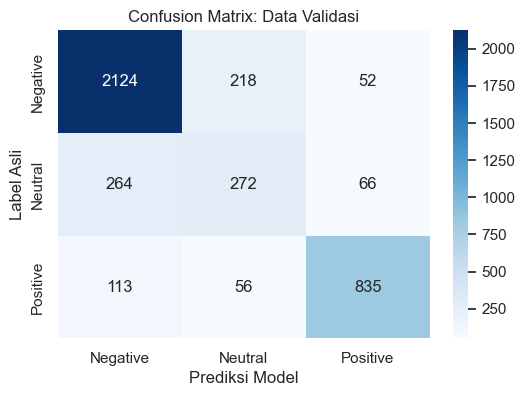

In [162]:
# eksekusi evaluasi model baseline
# data train
evaluasi_model(model, x_train_pad, y_train_enc, "Data Training")

# data validasi
evaluasi_model(model, x_val_pad, y_val_enc, "Data Validasi")

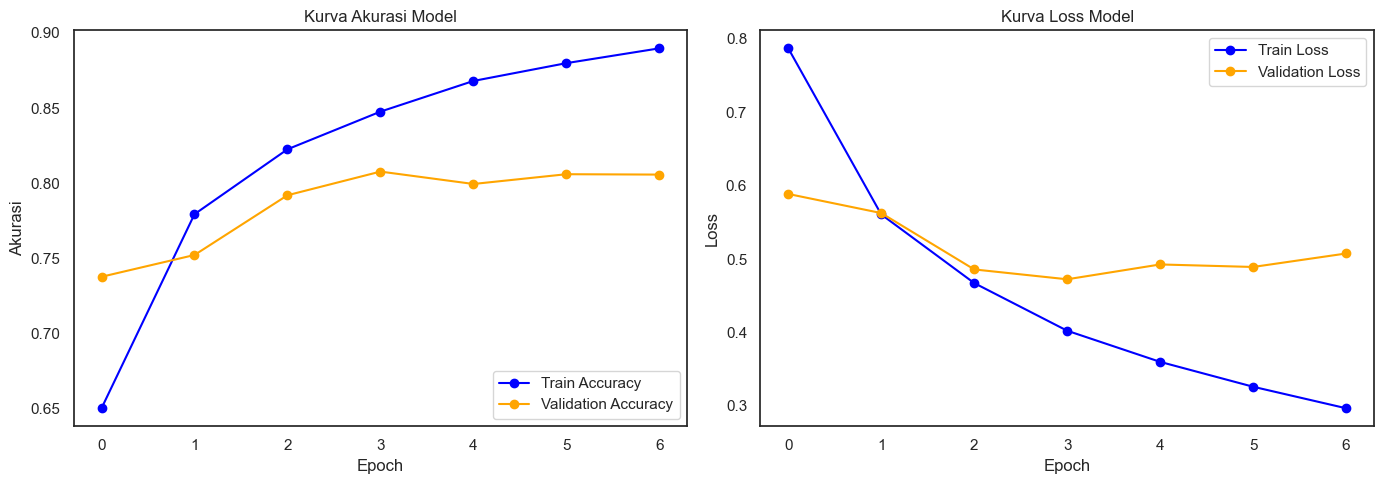

In [163]:
# eksekusi kurva akurasi dan loss
plot_learning_curves(history)

💡**Interpretasi**<br>
1. Performa pada Metrik
Untuk mengukur performa dari model dalam kasus ini, akan fokus ke 2 metrik utama yaitu `Recall` pada Label Negatif dan `Macro Avg F1-Score`. Berikut adalah hasilnya:<br>
- Recall Negative: 0.89 (89%)<br>
Model berhasil menangkap 89% dari total ulasan komplain/negatif yang sebenarnya. Meskipun angka ini cukup baik untuk sebuah baseline, masih ada 11% komplain (sekitar 263 ulasan) yang terlewat (ditebak sebagai netral/positif). Mengingat komplain sangat kritikal di Mobile JKN, kita harus menaikkan angka ini saat **tuning**.
- Macro Avg F1-Score: 0.73 (73%)<br>
Secara rata-rata keadilan untuk ketiga kelas, performa model berada di angka 73%. Angka ini anjlok cukup jauh dibandingkan data training (0.89). Hal ini membuktikan bahwa model sangat bias terhadap kelas mayoritas (Negative) dan gagal mengenali kelas lain dengan baik, terutama di kondisi data yang imbalance.

2. Pertimbangan Tunning
Melihat evaluasi baseline di atas, ada 3 alasan kuat mengapa hyperparameter tuning wajib dilakukan:
- Terjadi Overfitting:<br>
  Akurasi turun dari 88.9% (Training) ke 80.7% (Validasi).<br>
  Loss naik dari 0.30 (Training) ke 0.47 (Validasi).<br>
  Ini menunjukkan model terlalu menghafal data latih dan kesulitan saat dihadapkan pada data baru.<br>
- Performa Kelas 'Neutral' Sangat Buruk:<br>
Recall hanya 0.45 dan F1-Score hanya 0.47. Model kesulitan mengisolasi ulasan netral, kemungkinan besar sering salah menebaknya menjadi negatif atau positif.
- Ruang Peningkatan untuk Keluhan:<br>
Kita butuh pengaturan pembobotan (seperti class weight) atau penyesuaian arsitektur agar model bisa lebih agresif menangkap sisa 11% False Negative tanpa merusak performa tebakan untuk kelas Positive.


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step


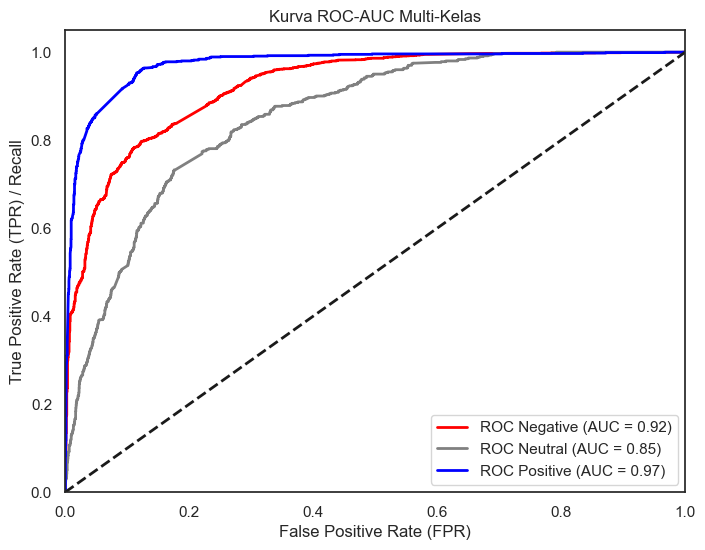

In [164]:
# eksekusi kurva roc-auc
y_val_pred_prob = model.predict(x_val_pad)
plot_roc_auc_multiclass(y_val_enc, y_val_pred_prob)

💡**Interpretasi**<br>
Discriminative power (daya pisah) model sudah jauh di atas tebakan acak untuk semua kelas. Namun, grafik ini mempertegas arah tuning yang harus dilakukan itu  fokus utama tuning adalah mengangkat kurva Neutral (abu-abu) agar lebih adil, sekaligus memaksimalkan kurva Negative (merah) ke arah sudut kiri atas.

### **MODEL HYPERPARAMETER TUNNING**

In [165]:
def build_model(hp):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(max_length,)),

        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=True
        ),

        tf.keras.layers.SpatialDropout1D(
            hp.Float("spatial_dropout", 0.2, 0.5, step=0.1)
        ),

        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                units=hp.Choice("lstm_units", [64, 96, 128]),
                return_sequences=True,
                dropout=hp.Float("lstm_dropout", 0.2, 0.4, step=0.1),
                recurrent_dropout=0.2
            )
        ),

        tf.keras.layers.GlobalMaxPooling1D(),

        tf.keras.layers.Dense(
            64,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Choice("l2_reg", [1e-4, 1e-5])
            )
        ),

        tf.keras.layers.Dropout(
            hp.Float("dense_dropout", 0.3, 0.6, step=0.1)
        ),

        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("learning_rate", [5e-4, 3e-4, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [167]:
# # Inisialisasi Keras Tuner (Menggunakan Random Search untuk kecepatan)
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=20,         
    executions_per_trial=1,
    directory="tuning_dir",
    project_name="bilstm_sentiment"
)

In [168]:
tuner.search(
    x_train_pad,
    y_train_enc,
    validation_data=(x_val_pad, y_val_enc),
    epochs=10,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2
        )
    ]
)

Trial 20 Complete [00h 02m 38s]
val_accuracy: 0.8075000047683716

Best val_accuracy So Far: 0.8102499842643738
Total elapsed time: 02h 45m 55s


In [169]:
# mengambil model terbaik
best_model = tuner.get_best_models(num_models=1)[0]

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print("LSTM Units:", best_hp.get("lstm_units"))
print("Spatial Dropout:", best_hp.get("spatial_dropout"))
print("LSTM Dropout:", best_hp.get("lstm_dropout"))
print("Dense Dropout:", best_hp.get("dense_dropout"))
print("Learning Rate:", best_hp.get("learning_rate"))
print("L2:", best_hp.get("l2_reg"))

Best Hyperparameters:
LSTM Units: 64
Spatial Dropout: 0.4
LSTM Dropout: 0.4
Dense Dropout: 0.4
Learning Rate: 0.0005
L2: 1e-05


In [172]:
# retrain model terbaik
final_model = tuner.hypermodel.build(best_hp)

history = final_model.fit(
    x_train_pad,
    y_train_enc,
    validation_data=(x_val_pad, y_val_enc),
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.6384 - loss: 0.7949 - val_accuracy: 0.7580 - val_loss: 0.5687
Epoch 2/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.7567 - loss: 0.5921 - val_accuracy: 0.7883 - val_loss: 0.4994
Epoch 3/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.8061 - loss: 0.4977 - val_accuracy: 0.7915 - val_loss: 0.4794
Epoch 4/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8331 - loss: 0.4317 - val_accuracy: 0.8098 - val_loss: 0.4549
Epoch 5/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 55s 144ms/step - accuracy: 0.8541 - loss: 0.3843 - val_accuracy: 0.7920 - val_loss: 0.4752
Epoch 6/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.8686 - loss: 0.3486 - val_accuracy: 0.8048 - val_loss: 0.4769


765/765 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step

===== EVALUATION DATA TRAINING =====
Loss     : 0.3017
Accuracy : 0.8891

 CLASSIFICATION REPORT - DATA TRAINING
              precision    recall  f1-score   support

    Negative       0.85      0.93      0.89      9577
     Neutral       0.90      0.74      0.81      7078
    Positive       0.89      0.92      0.91      7801

    accuracy                           0.87     24456
   macro avg       0.88      0.86      0.87     24456
weighted avg       0.87      0.87      0.87     24456



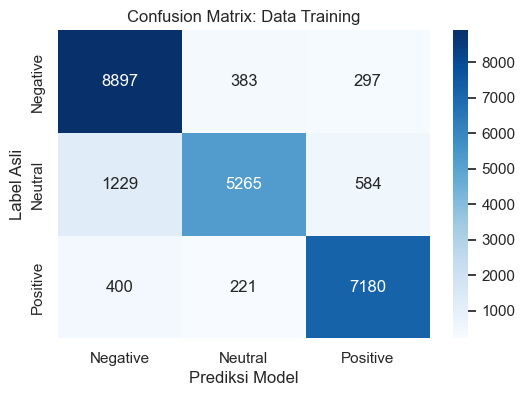

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

===== EVALUATION DATA VALIDASI =====
Loss     : 0.4726
Accuracy : 0.8077

 CLASSIFICATION REPORT - DATA VALIDASI
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87      2394
     Neutral       0.54      0.39      0.45       602
    Positive       0.83      0.87      0.85      1004

    accuracy                           0.81      4000
   macro avg       0.74      0.72      0.72      4000
weighted avg       0.80      0.81      0.80      4000



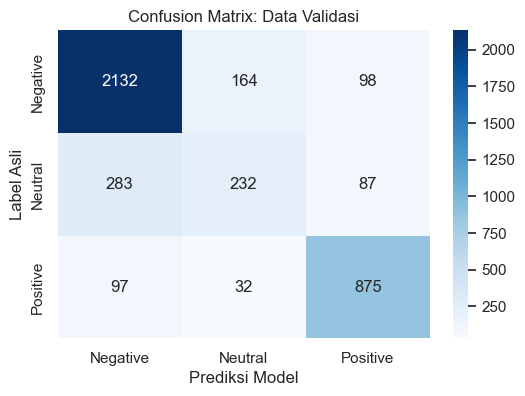

In [173]:
# eksekusi evaluasi model hasil tunned
# data train
evaluasi_model(final_model, x_train_pad, y_train_enc, "Data Training")

# data validasi
evaluasi_model(final_model, x_val_pad, y_val_enc, "Data Validasi")

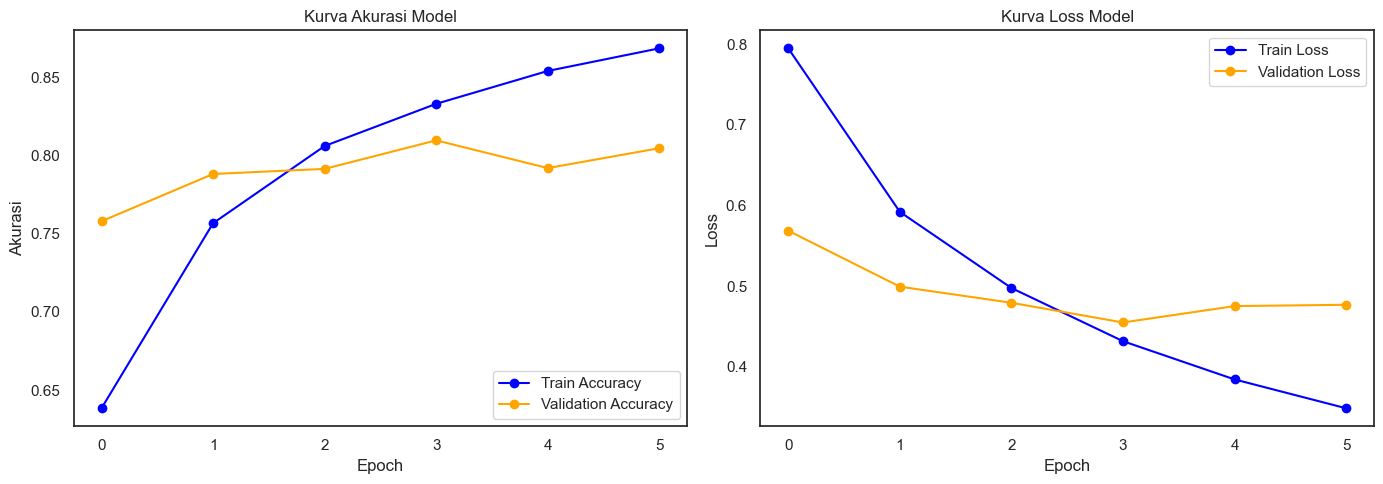

In [174]:
# eksekusi kurva akurasi dan loss
plot_learning_curves(history)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


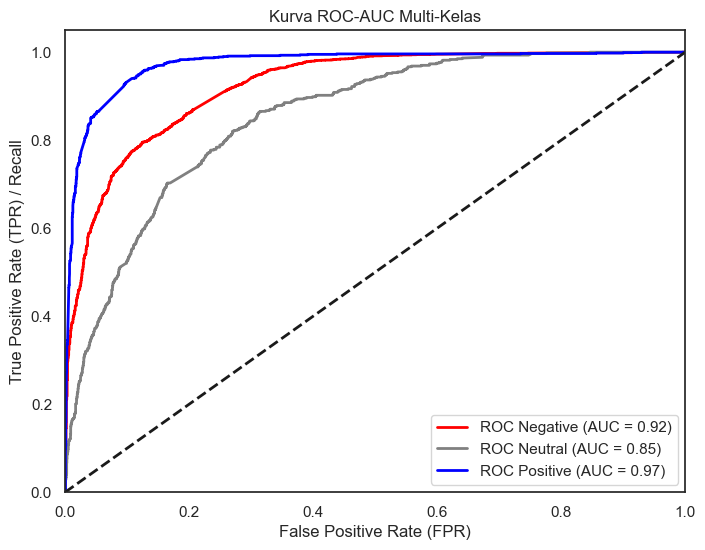

In [175]:
# eksekusi kurva roc-auc
y_val_pred_prob = final_model.predict(x_val_pad)
plot_roc_auc_multiclass(y_val_enc, y_val_pred_prob)

## **INFERENCES**

In [ ]:
# scraping data baru komen jkn terakhir (2026 Maret)
df_new = scraping.scrape_playstore_reviews(
    app_id='app.bpjs.mobile',
    target_count=50,
    batch_size=25,
    filter_score=None
)

df_new.head()

Mulai scraping 50 ulasan...



Mengambil review: 100%|██████████| 2/2 [00:03<00:00,  1.76s/batch]


Selesai! Total review: 50


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1cb21599-fce5-442a-9aba-3875da2329e8,Manik Luhut,https://play-lh.googleusercontent.com/a/ACg8oc...,setiap login selalu salah nik dan password. pa...,1,0,4.15.0,2026-03-01 14:05:23,NaN,NaT,4.15.0
1,b0c7066f-dded-4ce4-b336-65503f562f47,Acep Iman,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus,5,0,4.15.0,2026-03-01 13:59:57,Hi... Terima kasih atas review dan rating yang...,2026-03-02 12:59:06,4.15.0
2,408917a6-b34c-4965-bb1a-aed3afcdc95b,Eko Rusdiyatno,https://play-lh.googleusercontent.com/a/ACg8oc...,aplikasi sering error,1,0,4.15.0,2026-03-01 13:55:36,NaN,NaT,4.15.0
3,ef7769d6-e0c9-45bd-b36b-85339abfd26e,Endai,https://play-lh.googleusercontent.com/a/ACg8oc...,"aplikasi bagus utk mendapat informasi,pelayana...",5,0,4.15.0,2026-03-01 13:53:56,Hi... Terima kasih atas review dan rating yang...,2026-03-02 12:59:16,4.15.0
4,dc3bd8db-cca4-485e-8832-c65be180e39c,soni ati,https://play-lh.googleusercontent.com/a-/ALV-U...,pelayanan cepat,5,0,4.15.0,2026-03-01 13:52:51,Hi... Terima kasih atas review dan rating yang...,2026-03-02 12:59:27,4.15.0


In [204]:
# ambil text mentah
new_texts = df_new['content'].astype(str)

# cleaning
df_new['clean'] = new_texts.progress_apply(pipeline_cleaning_full)

# tokenizing pakai kolom clean
new_seq = tokenizer.texts_to_sequences(df_new['clean'])

# padding
new_pad = pad_sequences(new_seq, maxlen=max_length, padding='post')

# predict
pred_probs = model.predict(new_pad)
pred_class = pred_probs.argmax(axis=1)

# reverse mapping
label_mapping = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

df_new['predicted_label'] = [label_mapping[i] for i in pred_class]
df_new['confidence'] = pred_probs.max(axis=1)

df_new[['content', 'predicted_label', 'confidence']].head()

100%|██████████| 50/50 [00:00<00:00, 473.24it/s]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step


,content,predicted_label,confidence
0,setiap login selalu salah nik dan password. pa...,negative,0.867635
1,bagus,positive,0.975728
2,aplikasi sering error,negative,0.943704
3,"aplikasi bagus utk mendapat informasi,pelayana...",positive,0.965139
4,pelayanan cepat,positive,0.930677


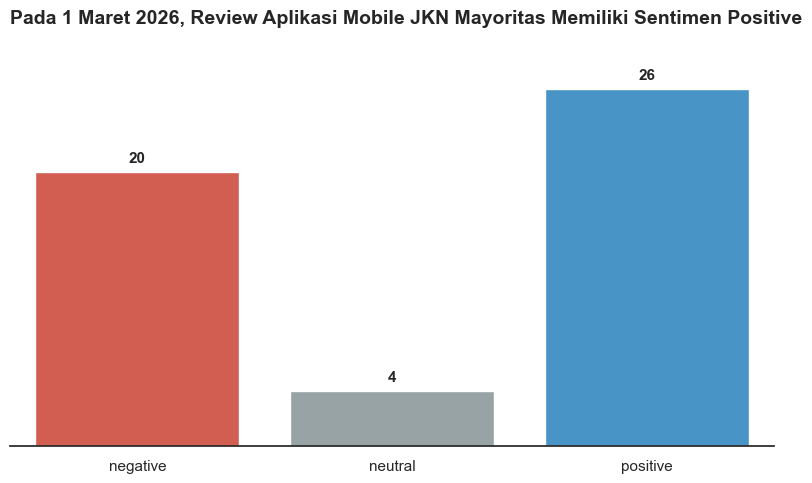

In [205]:
# visualisasi distribusi kelas
df_new['at'] = pd.to_datetime(df_new['at'])

start_date = df_new['at'].min()
end_date = df_new['at'].max()

date_range_text = f"{start_date.strftime('%d %B %Y')} - {end_date.strftime('%d %B %Y')}"


sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

custom_colors = {
    'negative': '#e74c3c',
    'neutral': '#95a5a6',
    'positive': '#3498db'
}

order = ['negative', 'neutral', 'positive']

ax = sns.countplot(
    data=df_new,
    x='predicted_label',
    order=order,
    palette=custom_colors
)

# Tambahkan angka di atas bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height:,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

# Tentukan kelas mayoritas otomatis
majority_class = df_new['predicted_label'].value_counts().idxmax()

plt.title(
    f'Pada 1 Maret 2026, Review Aplikasi Mobile JKN Mayoritas Memiliki Sentimen {majority_class.capitalize()}\n',
    fontsize=14,
    fontweight='bold',
    pad=20,
    loc='left'
)

plt.xlabel('')
plt.ylabel('')
ax.set_yticks([])

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

💡**Interpretasi**<br>
Berdasarkan analisis sentimen yang dilakukan untuk review Aplikasi Mobile JKN pada 1 Maret 2026, memiliki distribusi sentimen seperti berikut:
- Mayoritas Sentimen Positif: Secara keseluruhan, aplikasi mendapatkan sentimen yang cenderung baik. Dari total 50 ulasan yang divisualisasikan, mayoritas pengguna (26 ulasan) memberikan ulasan bersentimen positif.

- Porsi Sentimen Negatif yang Signifikan: Meskipun ulasan positif mendominasi, jumlah ulasan negatif tidak bisa diabaikan begitu saja. Terdapat 20 ulasan yang bersentimen negatif. Angka ini cukup besar dan menunjukkan ada ruang perbaikan yang cukup vital pada aplikasi.

- Sentimen Netral Sangat Minim: Hanya terdapat 4 ulasan bersentimen netral, yang mengindikasikan bahwa pengguna cenderung memiliki opini yang kuat (entah itu puas atau kecewa) setelah menggunakan aplikasi ini.

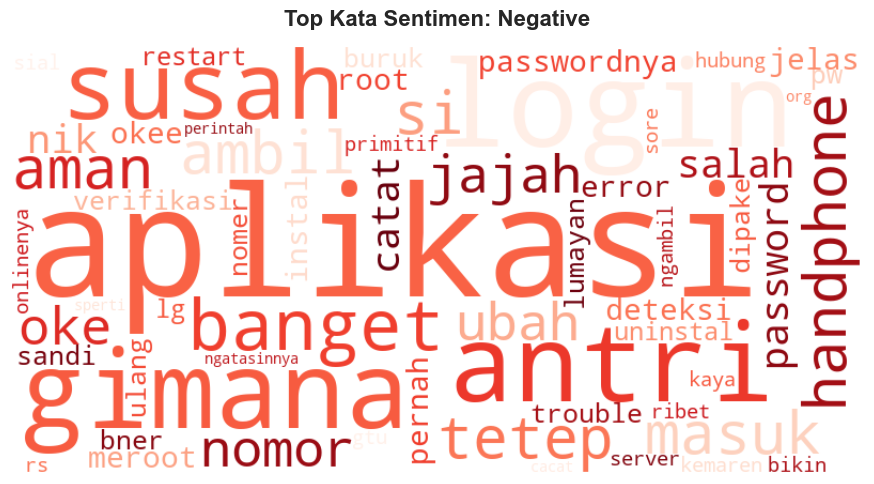

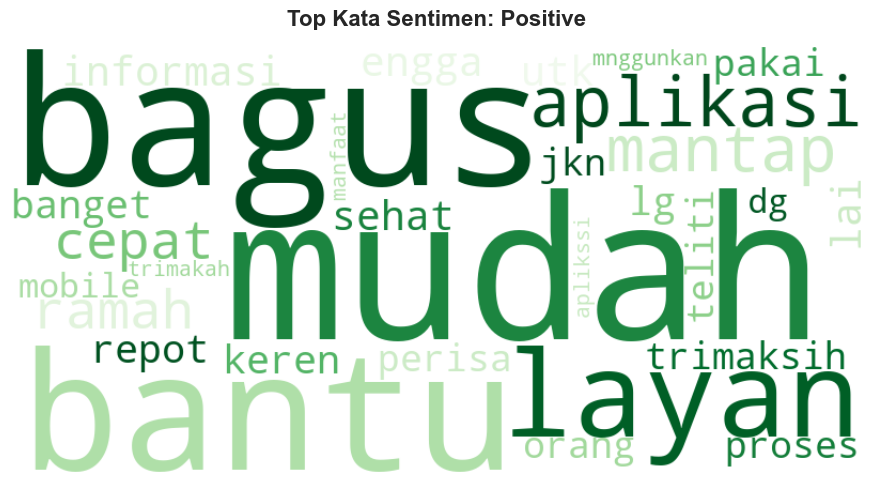

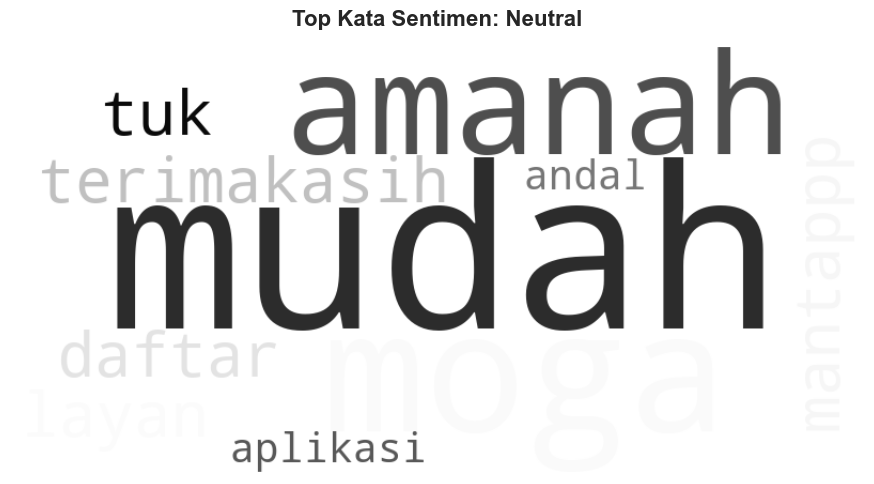

In [206]:
# visualisasi wordcloud untuk melihat distirubusi kata dalam setiap kelas/label
custom_stopwords = set(STOPWORDS)
id_stopwords = {
    "di", "ini", "saya", "bisa", "tidak", "nya", "buat", "dan", "yang", "yg",
    "ke", "dari", "aja", "untuk", "udah", "sudah", "dengan", "itu", "ada",
    "lagi", "terus", "padahal", "kalau", "kalo", "karena", "sama", "kok",
    "punya", "banyak", "sih", "juga", "atau", "jadi", "pas", "gak", "ga", 
    "ngga", "nggak", "kan", "tapi", "tp", "ya", "dong", "biar", "lebih",
    "sangat", "kali", "saat", "belum", "saja", "mau", "malah", "tolong", "kenapa"
}
custom_stopwords.update(id_stopwords)

labels = df_new['predicted_label'].unique()

for label in labels:
    text = ' '.join(df_new[df_new['predicted_label'] == label]['clean'].astype(str))

    if label == 'negative':
        cmap = 'Reds'     
    elif label == 'positive':
        cmap = 'Greens'   
    else:
        cmap = 'Greys'   

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords, 
        max_words=60,              
        colormap=cmap,          
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    
    plt.title(f'Top Kata Sentimen: {label.capitalize()}', fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

💡**Interpretasi**<br>
Berdasarkan distribusi sentimen pengguna terhadap pemakaian Aplikasi Mobile JKN, kita dapat menyoroti mengapa pengguna memberikan sentimen tersebut dengan menyoroti kata-kata yang paling sering muncul dalam ulasan:
- Sentimen Positif (Kepuasan Pengguna):
1. Kemudahan dan Kualitas: Kata "mudah", "bagus", dan "cepat" sangat mendominasi. Ini menunjukkan bahwa pengguna yang puas merasa antarmuka (UI/UX) aplikasi ini ramah pengguna dan proses yang mereka lakukan di dalam aplikasi berjalan dengan efisien.
2. Manfaat yang Dirasakan: Munculnya kata seperti "layanbantu" (layanan membantu), "bermanfaat", dan "terimakasih" menegaskan bahwa aplikasi ini dinilai sangat membantu mempermudah urusan administrasi atau layanan kesehatan pengguna.

- Sentimen Negatif (Kendala Utama):
1. Masalah Akses & Autentikasi: Kata "login", "password", dan "masuk" berukuran sangat besar. Ini adalah indikator kuat bahwa kendala terbesar yang dialami pengguna adalah kesulitan saat mencoba masuk ke dalam aplikasi (misalnya lupa password, OTP tidak masuk, atau error saat login).
2. Kendala Teknis & Kekecewaan: Kata-kata seperti "susah", "error", "gimana", dan "uninstal" menunjukkan rasa frustrasi. Pengguna kemungkinan mengalami bug atau kesulitan teknis ("error", "susah") yang berujung pada kebingungan ("gimana") atau bahkan keputusan untuk menghapus aplikasi ("uninstal"). Kata "antri" juga muncul, yang bisa jadi merujuk pada fitur antrean online yang bermasalah.

- Sentimen Netral:<br>
Karena hanya ada 4 ulasan, kata yang muncul sangat terbatas seperti "daftar", "mudah", dan "mantappp". Ulasan ini kemungkinan besar hanya berisi komentar singkat mengenai proses pendaftaran tanpa memberikan opini yang terlalu mendalam, meskipun nada kata-katanya cenderung positif.

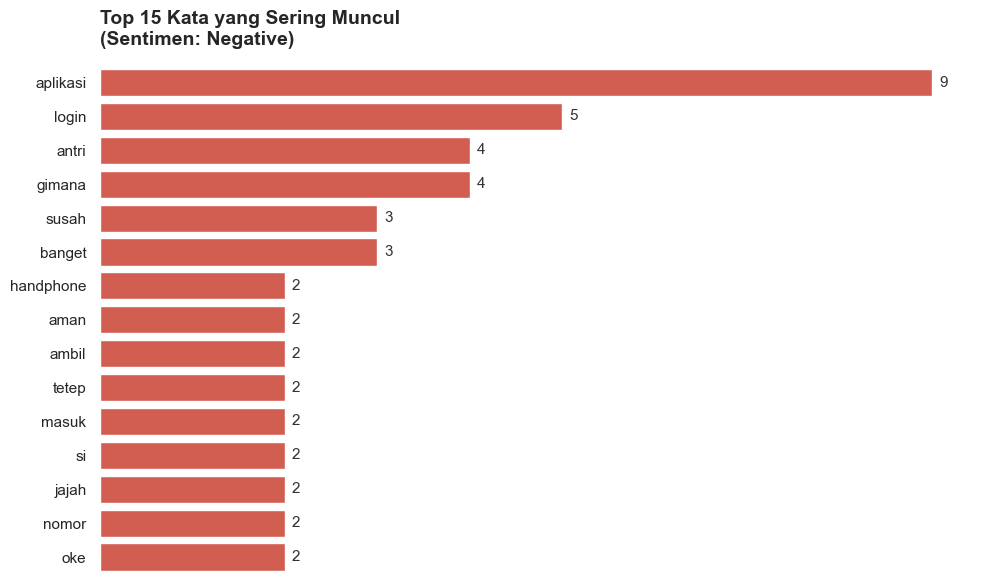

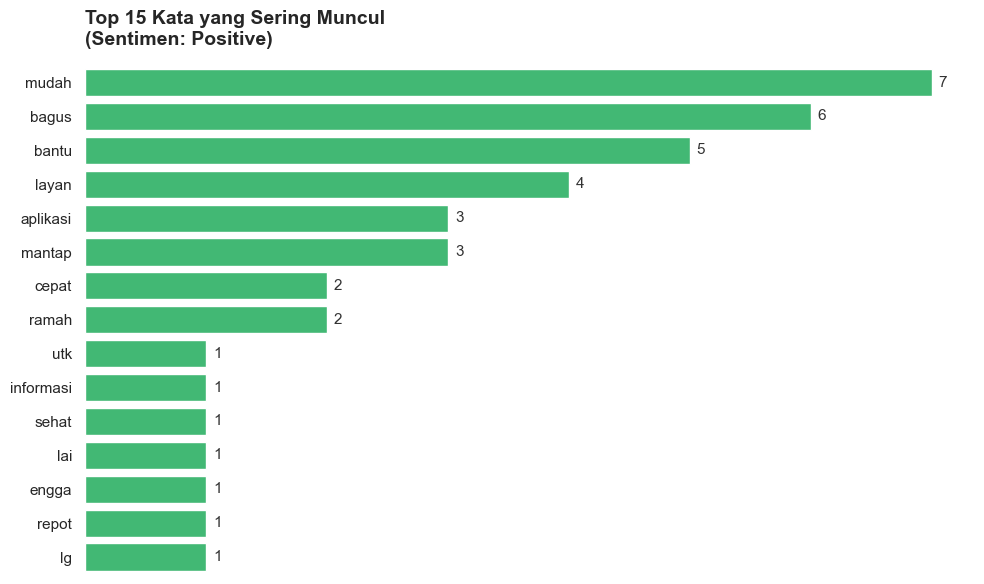

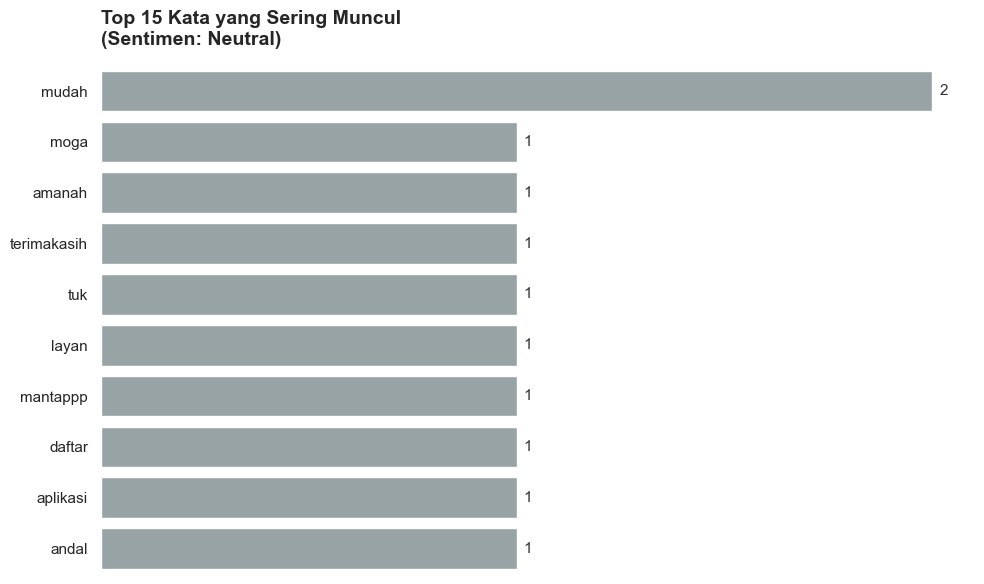

In [207]:
# visualisasi top 15 kata di setiap kelas
labels = df_new['predicted_label'].unique()

for label in labels:
    text = ' '.join(df_new[df_new['predicted_label'] == label]['clean'].astype(str))
    words = text.split()

    filtered_words = [word for word in words if word not in custom_stopwords]
    
    word_counts = Counter(filtered_words)
    top_15_words = word_counts.most_common(15)

    words_list = [item[0] for item in top_15_words]
    counts_list = [item[1] for item in top_15_words]

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")
    
    if label == 'negative':
        color = '#e74c3c' 
    elif label == 'positive':
        color = '#2ecc71' 
    else:
        color = '#95a5a6' 
        
    ax = sns.barplot(x=counts_list, y=words_list, color=color)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), # Jarak teks dari bar
                    textcoords='offset points',
                    fontsize=11, color='#333333')
        
    plt.title(f'Top 15 Kata yang Sering Muncul\n(Sentimen: {label.capitalize()})', 
              fontsize=14, fontweight='bold', pad=15, loc='left')
    plt.xlabel('') 
    plt.ylabel('')
    ax.set_xticks([]) 
    sns.despine(left=True, bottom=True) 
    
    plt.tight_layout()
    plt.show()

💡**Rekomendasi:**<br>
Aplikasi Mobile JKN dinilai mudah dan sangat membantu oleh mayoritas pengguna, namun pengembang aplikasi perlu segera memperbaiki beberapa hal. Berikut adalah hal yang perlu di improve/perbaiki sesuai skala prioritas berdasarkan tingkat urgensi yang diambil dari review pengguna:
1. Prioritas Utama (Jangka Pendek & Kritis)
- Perbaikan pada Sistem Login<br>
Tim teknis harus segera memeriksa log server terkait kegagalan login. Evaluasi alur lupa kata sandi (forgot password), pengiriman OTP (apakah terlambat atau tidak masuk sama sekali), dan sistem verifikasi data (NIK/No. BPJS). Pastikan server otentikasi mampu menangani lonjakan pengguna (traffic) agar tidak time-out.
- Penanganan Bug dan Error pada Aplikasi<br>
Lakukan pemantauan melalui tools crash analytics untuk melihat di halaman mana pengguna paling sering mengalami crash atau error. Rilis pembaruan (patch update) secepatnya untuk mengatasi bug utama yang menghambat fungsionalitas dasar aplikasi.
2. Prioritas Menengah (Optimalisasi Fitur)
-  Evaluasi Sistem Antrean Online ("Antri")<br>
Tim User Experience (UX) perlu menguji ulang (usability testing) alur pendaftaran antrean online. Pastikan sinkronisasi data antara aplikasi Mobile JKN dengan sistem di rumah sakit/faskes berjalan real-time agar pengguna tidak merasa fitur ini sia-sia.
- Peningkatan Layanan Bantuan (Helpdesk) di Dalam Aplikasi<br>
Sediakan fitur FAQ (Tanya Jawab) yang lebih interaktif atau integrasikan chatbot bantuan langsung di halaman depan, terutama di halaman login, sehingga pengguna yang kesulitan bisa langsung mendapatkan panduan tanpa harus marah dan memberikan rating buruk di app store.
3. Prioritas Jangka Panjang (Mempertahankan Kekuatan)
Saat merancang fitur baru di masa depan, pastikan tidak membuat aplikasi menjadi terlalu berat (bloated) atau mengubah antarmuka (UI) secara drastis yang bisa merusak pengalaman pengguna yang sudah dinilai baik. Pertahankan prinsip desain yang minimalis dan fungsional.